## Build model &compare

In [1]:
import pandas as pd 
import numpy as np

import model_utils
import adapter

In [2]:
start_date="2019-01-01"
test_date="2024-01-01"
end_date="2026-01-01"
freq="W"
n_states=3
window=104 #2 years （52*2）
random_seed=42

In [3]:
#forecast
train,test=model_utils.get_data(start_date,test_date,end_date,freq)
predicted_close = []
T = test.shape[0]-1 

model,log_likelihood=model_utils.build_hmm_and_score(train[-window:],n_states)

Loading data from cache...


In [4]:
import numpy as np
from hmmlearn.hmm import GaussianHMM


def make_return_features(df: pd.DataFrame) -> pd.DataFrame:
    feat = pd.DataFrame(index=df.index)
    feat["r_adj"] = np.log(df["Adj Close"]).diff()
    feat["r_o"]   = np.log(df["Open"]).diff()
    feat["r_h"]   = np.log(df["High"]).diff()
    feat["r_l"]   = np.log(df["Low"]).diff()
    feat = feat.dropna()
    return feat*100

X_train = make_return_features(train[['Open','High','Low','Adj Close']]).values
X_test  = make_return_features(test[['Open','High','Low','Adj Close']]).values

predicted_ret = []

#initial fit
model,log_likelihood=model_utils.build_hmm_and_score(train[-window:],n_states)
# rolling forecast
for t in range(len(X_test)):
    if t < window:
        X_window = np.vstack([X_train[-(window-t):], X_test[:t]])
    else:
        X_window = X_test[t-window:t]
    
    model.fit(X_window)
    
    # predict test[t] close
    hidden_states = model.predict(X_window)
    # use last day Adj Close + HMM block match prediction
    O = X_window[-window:, :]
    logP_O = model.score(O)
    
    # find most similar historical block (train + past test)
    min_diff = np.inf
    T_star = None
    full_hist = np.vstack([X_train, X_test[:t]])
    for i in range(len(full_hist)-window):
        O_hist = full_hist[i:i+window, :]
        logP_hist = model.score(O_hist)
        diff = abs(logP_O - logP_hist)
        if diff < min_diff:
            min_diff = diff
            T_star = i
    
    # block match prediction
    O4_T = X_window[-1, 3]
    O4_Tstar_next = full_hist[T_star+window, 3]
    O4_Tstar = full_hist[T_star+window-1, 3]
    sign_term = np.sign(logP_O - model.score(full_hist[T_star:T_star+window, :]))
    O4_next = O4_T + (O4_Tstar_next - O4_Tstar) * sign_term
    predicted_ret.append(O4_next)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


In [5]:
#add date to predicted_close
pred_ret=pd.Series(predicted_ret,index=test.index[-len(predicted_ret):])/300
real_price = test.loc[pred_ret.index, ("Adj Close", "^GSPC")].astype(float)
pred_price = real_price.shift(1) * np.exp(pred_ret)
pred_price.iloc[0] = real_price.iloc[0] * np.exp(pred_ret.iloc[0]) 
pred_price.name = "pred_price_1step"

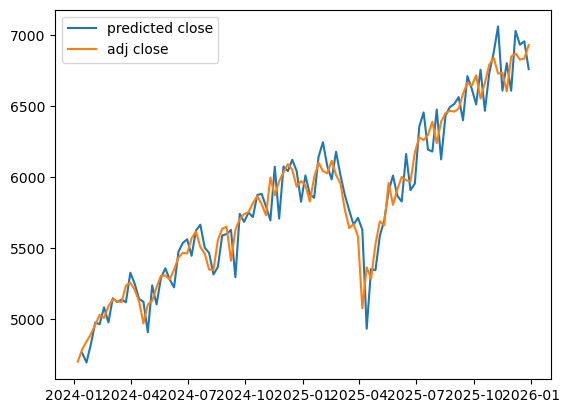

In [6]:
#draw predict close and adj close
import matplotlib.pyplot as plt
plt.plot(pred_price,label='predicted close')
plt.plot(test['Adj Close'],label='adj close')
plt.legend()
plt.show()

In [7]:
actual_log_ret = np.log(test["Adj Close"].iloc[:, 0].astype(float)).diff()

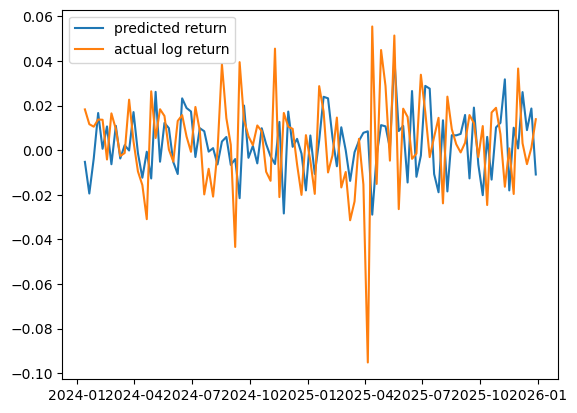

In [8]:
#draw actual return and predicted return
import matplotlib.pyplot as plt
plt.plot(pred_ret,label='predicted return')
plt.plot(actual_log_ret,label='actual log return')
plt.legend()
plt.show()


In [9]:
trade_cost=0.0001
df=test.copy()

#pred return
#pred_return=predicted_close.pct_change()
pred_return = pred_ret.copy().shift(-1)
adj_return=actual_log_ret.copy()

#only sell when predicted return lower than 0.03
weight = np.where(pred_return > 0.00,1,
                        np.where(pred_return > -0.03,0.8, 1),)
strat_weight=pd.Series(weight,index=test.index[-len(predicted_ret):])
#cost abs previous weight change
cost=abs(strat_weight-strat_weight.shift(1))*trade_cost
strat_return=strat_weight*adj_return-cost
strat_cumlog = strat_return.fillna(0).cumsum()
adj_cumlog   = adj_return.fillna(0).cumsum()
strat_cumret = np.exp(strat_cumlog) - 1
adj_cumret   = np.exp(adj_cumlog) - 1

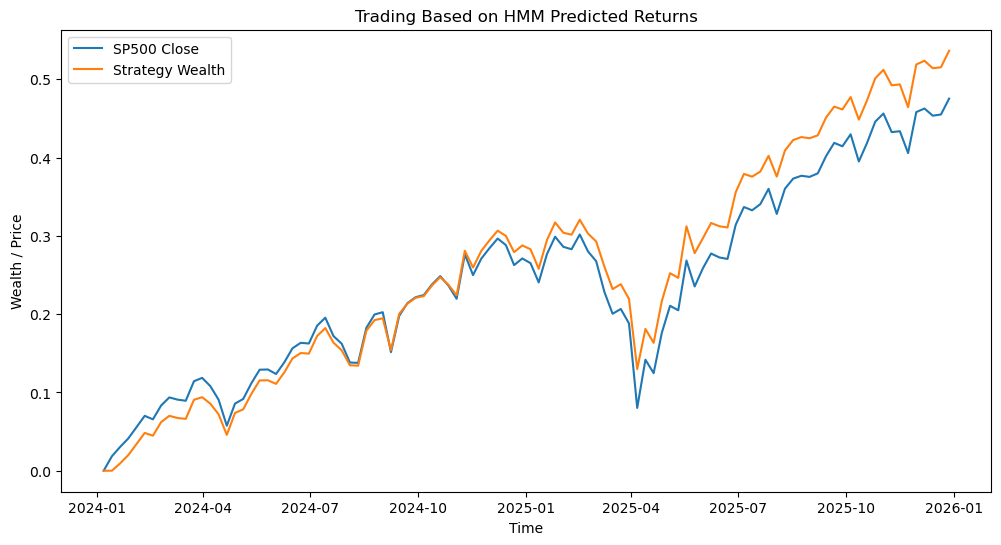

In [10]:
# compare with SP500
plt.figure(figsize=(12,6))
plt.plot(adj_cumret, label='SP500 Close')
plt.plot(strat_cumret, label='Strategy Wealth')
plt.xlabel('Time')
plt.ylabel('Wealth / Price')
plt.title('Trading Based on HMM Predicted Returns')
plt.legend()
plt.show()

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

eval_df = pd.concat(
    [pred_return.rename("pred"), adj_return.rename("real")],
    axis=1
).dropna()

y_pred = eval_df["pred"].values
y_true = eval_df["real"].values

# 2) R^2
r2 = r2_score(y_true, y_pred)

# 3) IC（Pearson）
ic = eval_df["pred"].corr(eval_df["real"], method="pearson")
rank_ic, rank_ic_p = spearmanr(eval_df["pred"], eval_df["real"])

# 4) Rolling IC + IC IR
win = 20
rolling_ic = eval_df["pred"].rolling(win).corr(eval_df["real"]).dropna()

ic_mean = rolling_ic.mean()
ic_std = rolling_ic.std(ddof=1)
ic_ir = np.nan if (ic_std == 0 or np.isnan(ic_std)) else ic_mean / ic_std

freq = 52 
ic_ir_ann = np.nan if pd.isna(ic_ir) else ic_ir * np.sqrt(freq)

print("===== Forecast Metrics =====")
print(f"N                  : {len(eval_df)}")
print(f"R^2                : {r2:.6f}")
print(f"IC (Pearson)       : {ic:.6f}")
print(f"Rank IC (Spearman) : {rank_ic:.6f} (p={rank_ic_p:.4g})")
print(f"Rolling IC mean({win}): {ic_mean:.6f}")
print(f"Rolling IC std ({win}): {ic_std:.6f}")
print(f"IC IR              : {ic_ir:.6f}")
print(f"Annualized IC IR   : {ic_ir_ann:.6f}")

===== Forecast Metrics =====
N                  : 102
R^2                : 0.246243
IC (Pearson)       : 0.515999
Rank IC (Spearman) : 0.539861 (p=4.756e-09)
Rolling IC mean(20): 0.622772
Rolling IC std (20): 0.177406
IC IR              : 3.510435
Annualized IC IR   : 25.314106
